# CNN using CIFAR-10 Dataset

In this lab, we will learn how to use the Keras library to build convolutional neural networks using CIFAR-10 dataset.

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. 
There are 50000 training images and 10000 test images.

The dataset is divided into five training batches and one test batch, each with 10000 images. 
The test batch contains exactly 1000 randomly-selected images from each class. 
The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another.
Between them, the training batches contain exactly 5000 images from each class.

In [1]:
# Import Keras and Packages

import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

In [2]:
# Additional packages for CNN

from keras.layers import Conv2D # to add convolutional layers
from keras.layers import Activation # to add activation function
from keras.layers import MaxPooling2D # to add pooling layers
from keras.layers import Flatten # to flatten data for fully connected layers

In [3]:
# import data
from keras.datasets import cifar10

# load data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [4]:
print("X_train original shape:", X_train.shape)
print("y_train original shape:", y_train.shape)
print("X_test original shape:", X_test.shape)
print("y_test original shape:", y_test.shape)

X_train original shape: (50000, 32, 32, 3)
y_train original shape: (50000, 1)
X_test original shape: (10000, 32, 32, 3)
y_test original shape: (10000, 1)


Notice that the dataset already contains four dimensions.
Since the channel dimension is already included, no reshaping is required.

In [5]:
# Normalize inputs from 0-255 to 0-1
X_train = X_train / 255 # normalize training data
X_test = X_test / 255 # normalize test data

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42,stratify=y_train)  

In [7]:
# one hot encode outputs to convert the target variable into binary categories
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1] # number of categories
print(num_classes)

10


In [8]:
from keras.layers import BatchNormalization
from keras.layers import Dropout

# Create CNN Model
model = Sequential()

model.add(Input(shape=(32,32,3)))

# Block 1
model.add(Conv2D(32,(3,3),kernel_initializer='he_uniform',padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(32,(3,3),kernel_initializer='he_uniform',padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

# Block 2
model.add(Conv2D(64,(3,3),kernel_initializer='he_uniform',padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(64,(3,3),kernel_initializer='he_uniform',padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

# Block 3
model.add(Conv2D(128,(3,3),kernel_initializer='he_uniform',padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(128,(3,3),kernel_initializer='he_uniform',padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

# Classification
model.add(Flatten())

model.add(Dense(128,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(10,activation='softmax'))

In [9]:
# training the model
from keras.optimizers import SGD

optimizer = SGD(learning_rate=0.001, momentum=0.95)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [11]:
# fit the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=200, verbose=2)

Epoch 1/20
200/200 - 104s - 520ms/step - accuracy: 0.2749 - loss: 2.0355 - val_accuracy: 0.1788 - val_loss: 2.3518
Epoch 2/20
200/200 - 98s - 490ms/step - accuracy: 0.3931 - loss: 1.6595 - val_accuracy: 0.3617 - val_loss: 1.7651
Epoch 3/20
200/200 - 98s - 488ms/step - accuracy: 0.4391 - loss: 1.5328 - val_accuracy: 0.4219 - val_loss: 1.6240
Epoch 4/20
200/200 - 103s - 517ms/step - accuracy: 0.4723 - loss: 1.4455 - val_accuracy: 0.4531 - val_loss: 1.5139
Epoch 5/20
200/200 - 124s - 621ms/step - accuracy: 0.4979 - loss: 1.3782 - val_accuracy: 0.5010 - val_loss: 1.3909
Epoch 6/20
200/200 - 122s - 609ms/step - accuracy: 0.5166 - loss: 1.3310 - val_accuracy: 0.5004 - val_loss: 1.4044
Epoch 7/20
200/200 - 99s - 496ms/step - accuracy: 0.5317 - loss: 1.2875 - val_accuracy: 0.5221 - val_loss: 1.3300
Epoch 8/20
200/200 - 98s - 488ms/step - accuracy: 0.5482 - loss: 1.2545 - val_accuracy: 0.5391 - val_loss: 1.2790
Epoch 9/20
200/200 - 99s - 496ms/step - accuracy: 0.5627 - loss: 1.2133 - val_accura

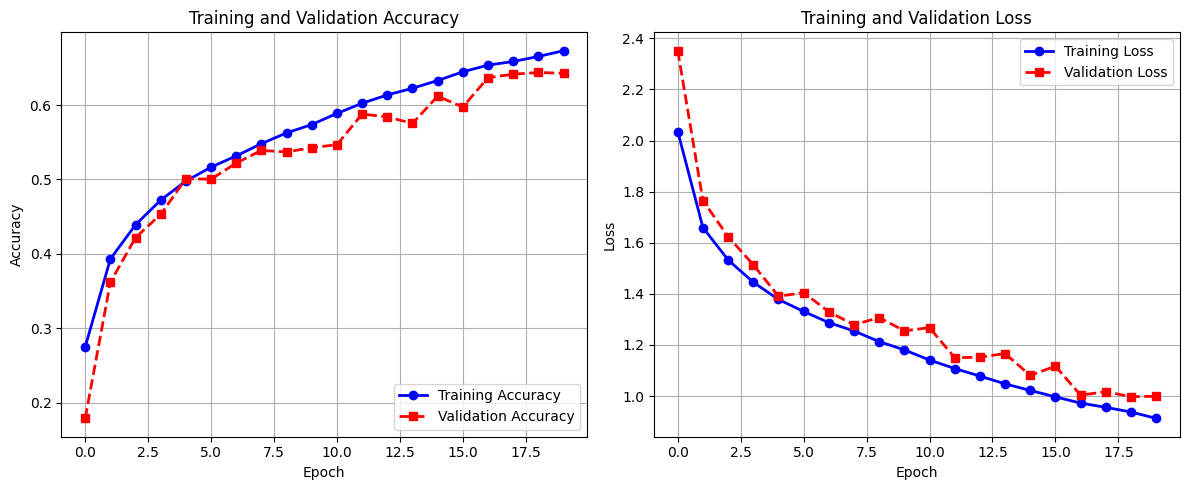

In [13]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(12,5))

# ==========================
# Accuracy Curve
# ==========================
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],color='blue',marker='o',linewidth=2,label='Training Accuracy')
plt.plot(history.history['val_accuracy'],color='red',marker='s',linestyle='--',linewidth=2,label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(loc='lower right')    

# ==========================
# Loss Curve
# ==========================
plt.subplot(1,2,2)
plt.plot(history.history['loss'], color='blue',marker='o',linewidth=2,label='Training Loss')
plt.plot(history.history['val_loss'],color='red',marker='s',linestyle='--',linewidth=2,label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)  
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()      

In [14]:
# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: {} \n Error: {}".format(scores[1], 1-scores[1]))

Accuracy: 0.6414999961853027 
 Error: 0.35850000381469727
